# 演習3

prob_3-2.csvのデータに対して，因子分析を行え．ただし因子数は2とする．

寄与率，因子負荷量，因子得点，およびバイプロットを求めよ．結果を観察し，考察も付記せよ．

In [52]:
!pip install factor-analyzer -q

In [53]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer


In [54]:
my_data = pd.read_csv('prob_3-2.csv', index_col=0)
zscored_array = zscore(my_data)  # 標準化
zscored_df = pd.DataFrame(zscored_array, index=my_data.index, columns=my_data.columns)
my_data_z = zscored_df
my_data_z

,国語,数学,英語,理科,社会
A,-1.412413,0.789011,0.843441,-0.340352,-0.997214
B,0.113497,0.107080,-1.105688,-1.571890,0.734789
C,1.084532,-0.698838,-0.092141,0.644878,-0.708547
D,0.113497,1.346955,0.921407,0.891186,-0.246679
E,0.252217,-0.016907,-1.417549,-0.586660,0.734789
F,-1.134975,-0.016907,0.765476,-0.832968,1.138923
G,1.015172,-2.062700,-0.248071,-1.424106,-0.593080
H,-1.343054,-1.256782,0.297685,0.398571,-0.766280
I,-0.649458,0.231068,-0.248071,0.891186,-1.632282
J,0.182857,0.107080,-1.495514,0.152263,0.561589


In [55]:
fa3 = FactorAnalyzer(n_factors=2)  # 因子数は2
fa3.fit(my_data_z)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=2, rotation_kwargs={})

In [56]:
# 因子負荷行列
loadings3 = fa3.loadings_
print("因子負荷行列:")
print(pd.DataFrame(loadings3, index=my_data_z.columns, columns=["Factor1", "Factor2"]))

因子負荷行列:
     Factor1   Factor2
国語  0.041599  0.344860
数学  0.560434  0.228007
英語  0.609630 -0.050516
理科  0.913288 -0.141379
社会 -0.176224  1.052569


In [57]:
# 分散（因子負荷量の二乗），寄与率，累積寄与率
variance3 = fa3.get_factor_variance()
print("寄与率:")
print(pd.DataFrame(variance3, index=["分散", "寄与率", "累積寄与率"], columns=["Factor1", "Factor2"]))

寄与率:
        Factor1   Factor2
分散     1.552616  1.301356
寄与率    0.310523  0.260271
累積寄与率  0.310523  0.570794


In [58]:
# 因子得点
Y3 = fa3.transform(my_data_z)
print("因子得点:")
print(pd.DataFrame(Y3, index=my_data_z.index, columns=["Factor1", "Factor2"]))

因子得点:
    Factor1   Factor2
A -0.073481 -1.164353
B -1.228497  0.323490
C  0.161428 -0.655500
D  0.928795 -0.236511
E -0.550949  0.656656
F -0.218789  1.165779
G -1.584984 -0.990606
H  0.186586 -0.350582
I  0.453671 -1.473019
J -0.006028  0.700325
K  1.932247  2.024321


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12496 (\N{KATAKANA LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

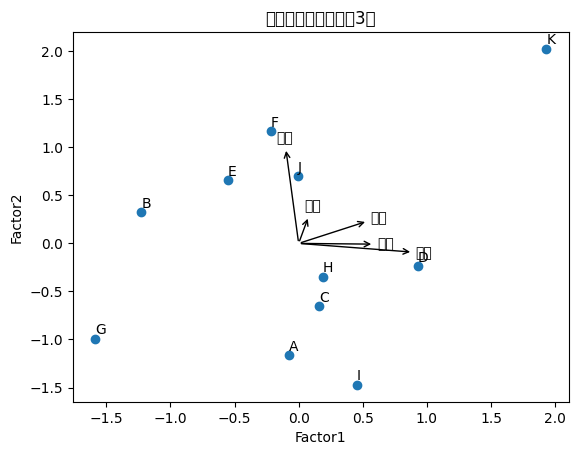

In [59]:
# バイプロット
factor1_3 = Y3[:, 0]
factor2_3 = Y3[:, 1]

fig, ax = plt.subplots()
plt.scatter(factor1_3, factor2_3)
for i in range(len(my_data_z.columns)):
    ax.annotate(my_data_z.columns[i], xy=(0, 0),
                xytext=(loadings3[i, 0], loadings3[i, 1]),
                arrowprops=dict(arrowstyle='<-'))
for i in range(len(Y3)):
    ax.annotate(my_data_z.index[i], xy=(factor1_3[i], factor2_3[i] + 0.05))
ax.set_xlabel('Factor1')
ax.set_ylabel('Factor2')
ax.set_title('バイプロット（演習3）')
plt.show()

## 演習3 考察

- Factor1は「数学・理科」などの理系科目との関連が強い因子と解釈できる
- Factor2は「国語・英語」などの文系科目との関連が強い因子と解釈できる
- バイプロットにより，各生徒の2因子上の位置関係が確認できる

# 演習4

prob_5-2.csvのデータに対して，因子分析を行え．ただし因子数は3とする．

寄与率，因子負荷量，因子得点，およびバイプロットを求めよ．結果を観察し，考察も付記せよ．

In [60]:
my_data4 = pd.read_csv('prob_5-2.csv')
my_data4 = my_data4.drop('No', axis=1)
zscored_array4 = zscore(my_data4)  # 標準化
zscored_df4 = pd.DataFrame(zscored_array4, index=my_data4.index, columns=my_data4.columns)
my_data4_z = zscored_df4
my_data4_z

,hjump,vjump,back,grip,50mrun,ljump
0,0.902894,-0.049580,-0.691865,-0.418878,-1.454863,-1.066489
1,1.203859,0.880038,-0.897166,-0.418878,-0.082351,-0.555065
2,0.000000,0.570165,1.566448,0.607784,-0.311103,0.143881
3,-1.504823,-1.908814,1.104520,1.634445,0.146401,0.842827
4,-0.902894,-0.669324,-2.026322,-0.213546,-0.768607,0.041596
5,1.203859,-0.979197,-0.794515,-0.829543,-0.311103,0.263213
6,1.805788,1.499782,-0.948491,-0.624210,1.290162,0.587115
7,-0.902894,-0.204516,-0.640540,-0.624210,-0.539855,-1.151727
8,-1.504823,-1.289069,-0.024636,1.018448,-1.226111,-0.691445
9,-0.601929,-2.218686,-0.897166,0.197119,-2.598624,-2.430286


In [61]:
fa4 = FactorAnalyzer(n_factors=3)  # 因子数は3
fa4.fit(my_data4_z)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(rotation_kwargs={})

In [62]:
# 因子負荷行列
loadings4 = fa4.loadings_
print("因子負荷行列:")
print(pd.DataFrame(loadings4, index=my_data4_z.columns, columns=["Factor1", "Factor2", "Factor3"]))

因子負荷行列:
         Factor1   Factor2   Factor3
hjump  -0.102843 -0.086649  1.049403
vjump   0.415230  0.070099  0.210538
back    0.250015  0.583330  0.090137
grip   -0.202266  1.046964 -0.137209
50mrun  1.090145 -0.203031 -0.043730
ljump   0.970568  0.033108 -0.182295


In [63]:
# 分散，寄与率，累積寄与率
variance4 = fa4.get_factor_variance()
print("寄与率:")
print(pd.DataFrame(variance4, index=["分散", "寄与率", "累積寄与率"], columns=["Factor1", "Factor2", "Factor3"]))

寄与率:
        Factor1   Factor2   Factor3
分散     2.416831  1.491148  1.207669
寄与率    0.402805  0.248525  0.201278
累積寄与率  0.402805  0.651330  0.852608


In [64]:
# 因子得点
Y4 = fa4.transform(my_data4_z)
print("因子得点:")
print(pd.DataFrame(Y4, index=my_data4_z.index, columns=["Factor1", "Factor2", "Factor3"]))

因子得点:
     Factor1   Factor2   Factor3
0  -1.422208 -0.607403  0.634051
1  -0.068161 -0.266360  1.153863
2  -0.282448  0.415962 -0.105866
3   0.468945  1.625366 -1.188158
4  -0.749300 -0.391977 -0.895098
5  -0.266653 -0.579202  1.105989
6   1.291006 -0.054371  1.928106
7  -0.765857 -0.949993 -1.037407
8  -1.050378  0.603430 -1.471347
9  -2.438171 -0.337647 -0.820675
10  0.201627  0.265741  0.079821
11 -0.498989 -1.181605  0.938548
12  0.951493 -0.031506  0.034675
13  0.084222 -0.072756 -0.602883
14  0.851521 -1.038088  0.602860
15  0.547581 -0.197124  0.651923
16  1.073506 -1.560134  0.209037
17  0.963670 -0.272125  0.939536
18  0.048758  0.788533  0.561352
19  0.770719  0.252927 -0.183793
20  1.418215  2.163037  1.175102
21  1.568553  2.914502  0.191702
22 -1.010962 -0.798688 -2.206118
23 -1.599678 -0.812602 -1.672881
24 -0.087012  0.122086 -0.022337


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12496 (\N{KATAKANA LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

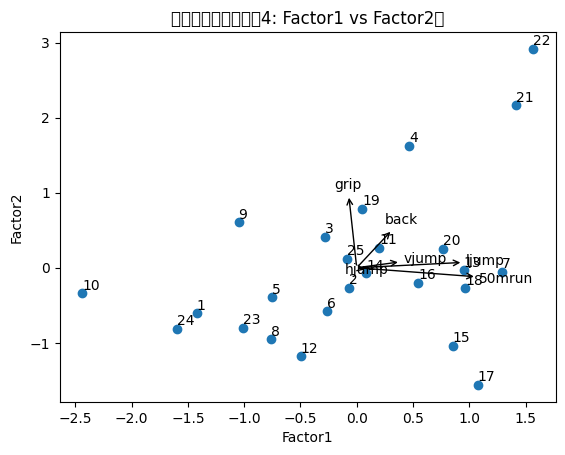

In [65]:
# バイプロット（Factor1 vs Factor2）
factor1_4 = Y4[:, 0]
factor2_4 = Y4[:, 1]

fig, ax = plt.subplots()
plt.scatter(factor1_4, factor2_4)
for i in range(len(my_data4_z.columns)):
    ax.annotate(my_data4_z.columns[i], xy=(0, 0),
                xytext=(loadings4[i, 0], loadings4[i, 1]),
                arrowprops=dict(arrowstyle='<-'))
for i in range(len(Y4)):
    ax.annotate(f"{i+1}", xy=(factor1_4[i], factor2_4[i] + 0.05))
ax.set_xlabel('Factor1')
ax.set_ylabel('Factor2')
ax.set_title('バイプロット（演習4: Factor1 vs Factor2）')
plt.show()

## 演習4 考察

- Factor1は「反復横飛び・垂直跳び・走り幅跳び」など瞬発力・敏捷性に関わる因子と解釈できる
- Factor2は「背筋力・握力」など筋力に関わる因子と解釈できる
- Factor3は「50m走」など持久力・走力に関わる因子と解釈できる

# 演習5

prob_7-1.csvは動物のデータである．

階層的クラスタリングを行い，どの動物が似ていて，どの動物が似ていないかをデンドログラムにより視覚化せよ．

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
import matplotlib
matplotlib.rcParams["font.family"] = "IPAexGothic"  # 日本語フォント設定（環境依存）


In [67]:
my_data5 = pd.read_csv('prob_7-1.csv', index_col=0)
my_data5

,小さい,中くらい,大きい,夜行性,2本足,4本足,髪を持つ,有蹄類,たてがみ,羽あり,縞あり,狩猟,走る,飛ぶ,泳ぐ,草食性
動物名,,,,,,,,,,,,,,,,
ハト,1,0,0,0.0,1,0,0,0,0,1,0.0,0,0,1,0,0.5
メンドリ,1,0,0,0.0,1,0,0,0,0,1,0.0,0,0,0,0,0.5
カモ,1,0,0,0.0,1,0,0,0,0,1,0.3,0,0,1,1,0.5
ガチョウ,1,0,0,0.0,1,0,0,0,0,1,0.0,0,0,1,1,0.5
フクロウ,1,0,0,1.0,1,0,0,0,0,1,0.0,1,0,1,0,0.0
タカ,1,0,0,0.0,1,0,0,0,0,1,0.0,1,0,1,0,0.0
ワシ,0,1,0,0.0,1,0,0,0,0,1,0.0,1,0,1,0,0.0
キツネ,0,1,0,0.5,0,1,1,0,0,0,0.0,1,0,0,0,0.0
イヌ,0,1,0,0.0,0,1,1,0,0,0,0.0,0,1,0,0,0.0


/tmp/ipykernel_1740/1907895812.py:12: UserWarning: Glyph 12459 (\N{KATAKANA LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/1907895812.py:12: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/1907895812.py:12: UserWarning: Glyph 12460 (\N{KATAKANA LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/1907895812.py:12: UserWarning: Glyph 12481 (\N{KATAKANA LETTER TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/1907895812.py:12: UserWarning: Glyph 12519 (\N{KATAKANA LETTER SMALL YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/1907895812.py:12: UserWarning: Glyph 12454 (\N{KATAKANA LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/1907895812.py:12: UserWarning: Glyph 12495 (\N{KATAKANA LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_lay

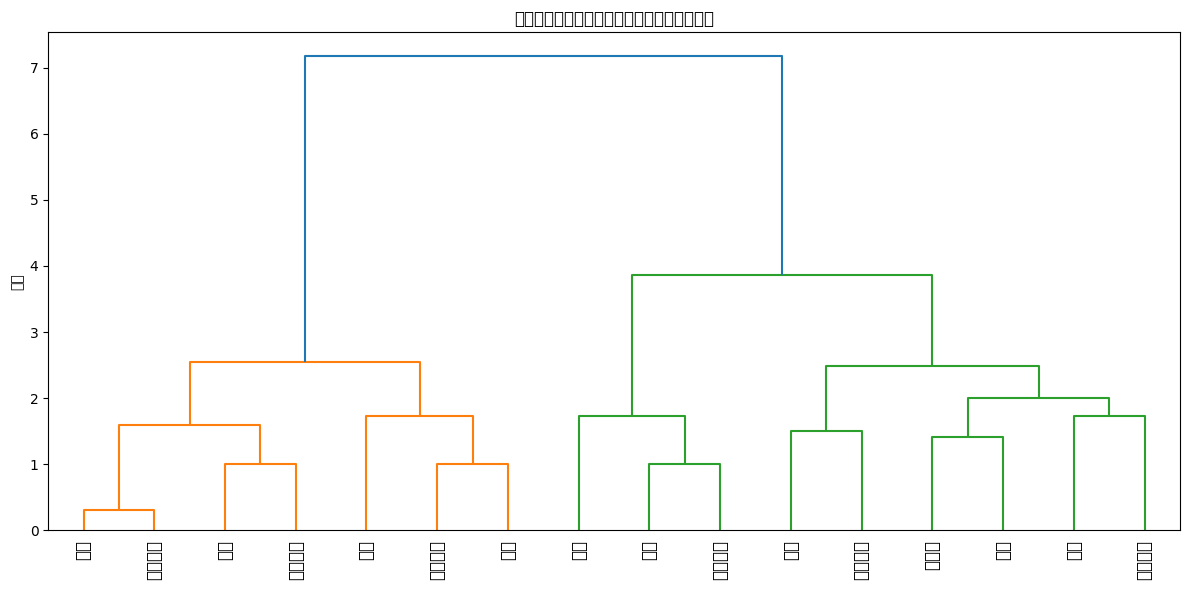

In [68]:
# 階層的クラスタリングの実行（ウォード法）
result5 = hierarchy.linkage(
    my_data5,
    metric='euclidean',
    method='ward')

# デンドログラムの描画
fig, ax = plt.subplots(figsize=(12, 6))
hierarchy.dendrogram(result5, labels=my_data5.index, ax=ax, leaf_rotation=90)
ax.set_title('動物の階層的クラスタリング（ウォード法）')
ax.set_ylabel('距離')
plt.tight_layout()
plt.show()

# 演習6

prob_7-2.csvは自動車のデータである．

クラスタ数を3として，k-means法による非階層的クラスタリングを行い，各クラスタのサンプル数を集計せよ．

In [69]:
from sklearn.cluster import KMeans
from scipy.stats import zscore


In [70]:
my_data6 = pd.read_csv('prob_7-2.csv', index_col=0)
my_data6

,排気量,燃費（WLTC）,全長,全幅,全高,価格,総重量
車名,,,,,,,
3シリーズ,1998.0,13.0,4720,1825,1440,548,1815.0
CX-60,2488.0,14.2,4740,1890,1685,299,1955.0
BRZ,2387.0,12.0,4265,1775,1310,308,1480.0
GR-86,2387.0,12.0,4265,1775,1310,279,1480.0
N-BOXカスタム,658.0,21.2,3395,1475,1790,178,1130.0
アウトランダー（PHEV）,2359.0,16.6,4710,1860,1740,484,2285.0
アルファード,2493.0,10.8,4945,1850,1935,359,2360.0
エクストレイル（EV）,1497.0,19.7,4660,1840,1720,319,2015.0
オーラ（EV）,1198.0,27.2,4045,1735,1525,265,1535.0


In [71]:
# 欠損値を除去してから標準化
my_data6_clean = my_data6.dropna()
zscored_array6 = zscore(my_data6_clean)
zscored_df6 = pd.DataFrame(zscored_array6, index=my_data6_clean.index, columns=my_data6_clean.columns)

# k-meansクラスタリング（クラスタ数=3）
result6 = KMeans(n_clusters=3, n_init="auto").fit(zscored_df6)

# 各クラスタのサンプル数
my_data6_clustered = my_data6_clean.assign(cluster=result6.labels_)
print("各クラスタのサンプル数:")
print(my_data6_clustered.groupby("cluster").size())
my_data6_clustered

各クラスタのサンプル数:
cluster
0    6
1    9
2    7
dtype: int64


,排気量,燃費（WLTC）,全長,全幅,全高,価格,総重量,cluster
車名,,,,,,,,
3シリーズ,1998.0,13.0,4720,1825,1440,548,1815.0,0
CX-60,2488.0,14.2,4740,1890,1685,299,1955.0,2
BRZ,2387.0,12.0,4265,1775,1310,308,1480.0,0
GR-86,2387.0,12.0,4265,1775,1310,279,1480.0,0
N-BOXカスタム,658.0,21.2,3395,1475,1790,178,1130.0,1
アウトランダー（PHEV）,2359.0,16.6,4710,1860,1740,484,2285.0,2
アルファード,2493.0,10.8,4945,1850,1935,359,2360.0,2
エクストレイル（EV）,1497.0,19.7,4660,1840,1720,319,2015.0,2
オーラ（EV）,1198.0,27.2,4045,1735,1525,265,1535.0,1


# 演習7

prob_7-2.csvは自動車のデータである．

階層的クラスタリングを行い，デンドログラムを作成せよ．

/tmp/ipykernel_1740/104567253.py:17: UserWarning: Glyph 12459 (\N{KATAKANA LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/104567253.py:17: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/104567253.py:17: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/104567253.py:17: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/104567253.py:17: UserWarning: Glyph 12484 (\N{KATAKANA LETTER TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/104567253.py:17: UserWarning: Glyph 12522 (\N{KATAKANA LETTER RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1740/104567253.py:17: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.ti

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12455 (\N{KATAKANA LETTER SMALL E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12474 (\N{KATAKANA LETTER ZU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12499 (\N{KATAKANA LETTER BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


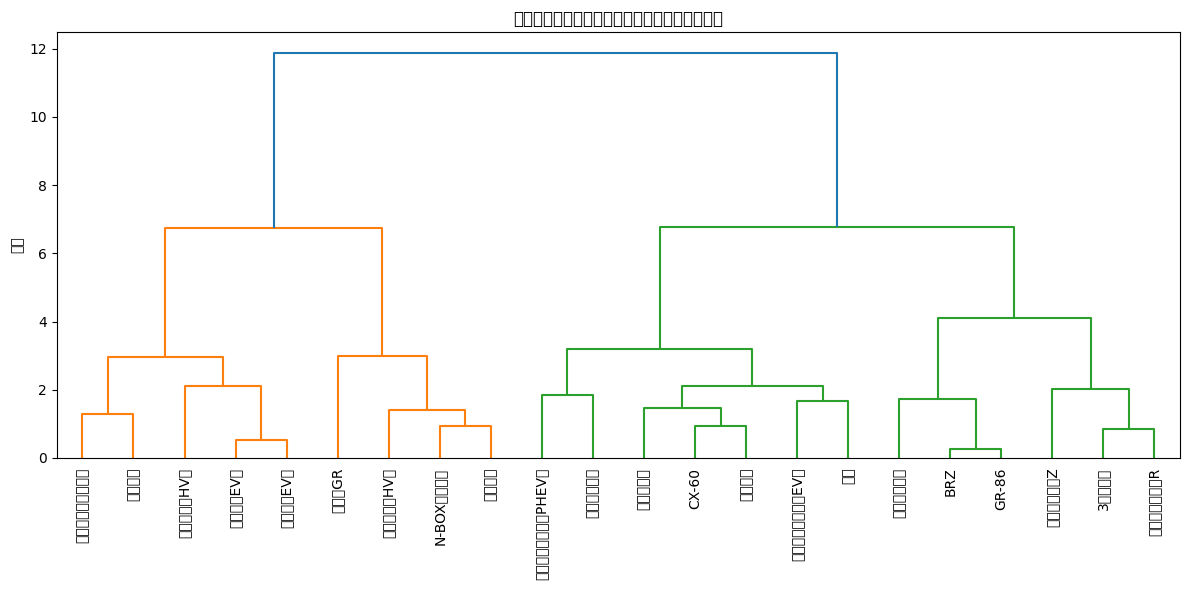

In [72]:
# 欠損値を除去してから標準化
my_data6_clean = my_data6.dropna()
zscored_array7 = zscore(my_data6_clean)
zscored_df7 = pd.DataFrame(zscored_array7, index=my_data6_clean.index, columns=my_data6_clean.columns)

# 階層的クラスタリングの実行（ウォード法）
result7 = hierarchy.linkage(
    zscored_df7,
    metric='euclidean',
    method='ward')

# デンドログラムの描画
fig, ax = plt.subplots(figsize=(12, 6))
hierarchy.dendrogram(result7, labels=my_data6_clean.index, ax=ax, leaf_rotation=90)
ax.set_title('自動車の階層的クラスタリング（ウォード法）')
ax.set_ylabel('距離')
plt.tight_layout()
plt.show()

# 演習8

教育用標準データセット（SSDSE）のSSDSE-C（都道府県庁所在市別・家計消費データ）に対してクラスタ分析を適用し，消費行動が類似している都道府県のクラスタを作る．

(1) データセットを読み込み，各都道府県庁所在地を特徴ベクトルで表現する

(2) K-meansをK=1〜10で実行し，WCSSのエルボープロットを描く

(3) (2)の結果に基づきKを選び，K-meansを実行してクラスタを確認する

In [73]:
# SSDSE-C-2026.csv を読み込む（このnotebookと同じフォルダに置いてください）
ssdse_raw = pd.read_csv("SSDSE-C-2026.csv", encoding="shift_jis", header=1, index_col=1)
# 地域コード・市・世帯人員などの非消費列を除外し，数値列のみ使用
ssdse_raw = ssdse_raw.drop(columns=["地域コード", "市", "世帯人員"], errors="ignore")
# 全国行を除外（都道府県のみ対象）
ssdse_data = ssdse_raw.drop(index="全国", errors="ignore")
ssdse_data = ssdse_data.apply(pd.to_numeric, errors="coerce").dropna(axis=1)
print("データの形状:", ssdse_data.shape)
ssdse_data.head()

データの形状: (47, 225)


,食料（合計）,01 穀類,米,食パン,他のパン,生うどん・そば,乾うどん・そば,パスタ,中華麺,カップ麺,...,すし（外食）,和食,中華食,洋食,焼肉,ハンバーガー,他の主食的外食,喫茶代,飲酒代,学校給食
都道府県,,,,,,,,,,,,,,,,,,,,,
北海道,1007628,91994,35984,9366,19957,3515,2057,1558,4663,6428,...,17303,23714,3580,18638,8162,4823,26979,7456,21073,12205
青森県,1010524,87921,29339,9621,19671,3387,2771,1288,6192,8326,...,14942,16945,3117,9401,7194,4529,20519,4626,11361,1247
岩手県,1042728,86816,28660,8716,20144,3730,2603,1423,6475,7023,...,14794,14403,2200,7384,7674,4926,47895,7112,20520,10972
宮城県,1065052,86729,26933,10030,21414,3400,2138,1616,5185,7189,...,17554,28348,3858,14261,7886,6238,24913,10027,20529,10741
秋田県,1030621,82086,24802,8532,18253,3828,3943,1361,6331,7215,...,16134,19689,2598,8868,8536,4181,25919,6027,16841,13111


In [74]:
# (1) 標準化して特徴ベクトル化
zscored_ssdse = zscore(ssdse_data)
zscored_ssdse_df = pd.DataFrame(zscored_ssdse, index=ssdse_data.index, columns=ssdse_data.columns)
print("特徴ベクトルの形状:", zscored_ssdse_df.shape)
zscored_ssdse_df.head()

特徴ベクトルの形状: (47, 225)


,食料（合計）,01 穀類,米,食パン,他のパン,生うどん・そば,乾うどん・そば,パスタ,中華麺,カップ麺,...,すし（外食）,和食,中華食,洋食,焼肉,ハンバーガー,他の主食的外食,喫茶代,飲酒代,学校給食
都道府県,,,,,,,,,,,,,,,,,,,,,
北海道,-0.869042,0.325921,1.830252,-0.900096,-1.325127,-0.344644,-0.554960,0.520307,-0.006823,0.723590,...,0.386494,-0.541705,-0.754322,1.311707,-0.311752,-1.345443,-1.029091,-0.738328,0.540895,0.805650
青森県,-0.828175,-0.477326,0.006552,-0.726051,-1.445159,-0.534167,0.771112,-1.228288,1.938819,3.000756,...,-0.442374,-1.602419,-1.006102,-0.905975,-0.708093,-1.611208,-1.365804,-1.837494,-1.159911,-2.304705
岩手県,-0.373727,-0.695247,-0.179798,-1.343740,-1.246644,-0.026305,0.459095,-0.353991,2.298934,1.437454,...,-0.494332,-2.000755,-1.504767,-1.390230,-0.511560,-1.252335,0.061108,-0.871937,0.444052,0.455671
宮城県,-0.058701,-0.712404,-0.653768,-0.446897,-0.713636,-0.514918,-0.404523,0.895931,0.657419,1.636616,...,0.474612,0.184451,-0.603145,0.260847,-0.424758,-0.066335,-1.136777,0.260243,0.445628,0.390103
秋田県,-0.544575,-1.628063,-1.238615,-1.469326,-2.040281,0.118798,2.947801,-0.755520,2.115695,1.667810,...,-0.023902,-1.172429,-1.288334,-1.033941,-0.158620,-1.925787,-1.084341,-1.293349,-0.200230,1.062812


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

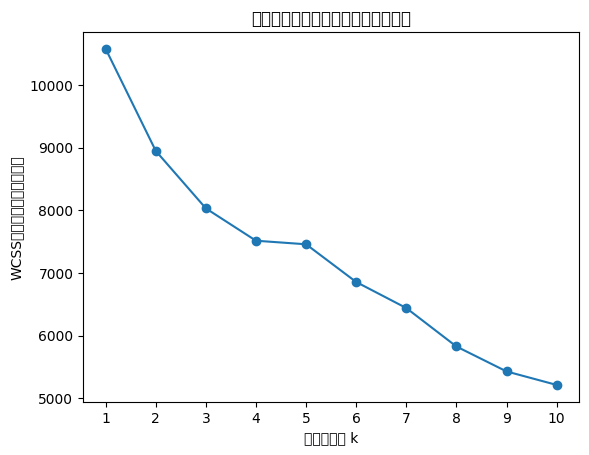

In [75]:
# (2) K=1〜10でk-meansを実行しWCSS（inertia）をプロット
k_range = range(1, 11)
inertias = [KMeans(n_clusters=k, n_init="auto", random_state=0).fit(zscored_ssdse_df).inertia_ for k in k_range]

my_df8 = pd.DataFrame({"k": list(k_range), "inertia": inertias})
my_df8.plot(x='k', y='inertia', style='o-', legend=False)
plt.xlabel('クラスタ数 k')
plt.ylabel('WCSS（クラスタ内平方和）')
plt.title('エルボー法によるクラスタ数の選定')
plt.xticks(list(k_range))
plt.show()

In [76]:
# (3) エルボー法の結果に基づきK=4を選択してk-meansを実行
K = 4  # エルボー法から選んだクラスタ数
result8 = KMeans(n_clusters=K, n_init="auto", random_state=0).fit(zscored_ssdse_df)

ssdse_clustered = ssdse_data.assign(cluster=result8.labels_)
for k in range(K):
    members = ssdse_clustered[ssdse_clustered["cluster"] == k].index.tolist()
    print(f"クラスタ {k+1} ({len(members)}都市):")
    print(", ".join(members))

クラスタ 1 (8都市):
石川県, 岐阜県, 愛知県, 滋賀県, 京都府, 大阪府, 兵庫県, 奈良県
クラスタ 2 (20都市):
福井県, 三重県, 和歌山県, 鳥取県, 島根県, 岡山県, 広島県, 山口県, 徳島県, 香川県, 愛媛県, 高知県, 福岡県, 佐賀県, 長崎県, 熊本県, 大分県, 宮崎県, 鹿児島県, 沖縄県
クラスタ 3 (9都市):
北海道, 青森県, 岩手県, 宮城県, 秋田県, 山形県, 福島県, 新潟県, 富山県
クラスタ 4 (10都市):
茨城県, 栃木県, 群馬県, 埼玉県, 千葉県, 東京都, 神奈川県, 山梨県, 長野県, 静岡県


## 演習8 考察

- エルボープロットにより，WCSSの減少が緩やかになる点（エルボー点）でクラスタ数を選定した
- 各クラスタに属する都市を確認することで，地理的・文化的に近い都市が同クラスタに属する傾向が見られる